In [1]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

import pandas as pd
import numpy as np
from matplotlib  import pyplot as plt
import seaborn as sns

2025-05-23 21:36:16.409978: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#from car_price_prossessing_functions import *
from data_preprocessing import *

In [3]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense


In [4]:
model_yaml_path = "/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/AI_Workshop/config/data_config.yaml"
cars_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/car_prices.csv'
population_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/states_populations_yr2015.csv'

In [5]:
config = load_config(model_yaml_path)

df = load_data(cars_file_path); pop_df = load_data(population_file_path) #.drop('population (2015)', axis=1)

df = process_dates(df)

df = define_market(
    df, market_vars=config['var_of_interest']['marketvar'], 
    market_label='market', market_code='marketid', minsize=20, DropSmallMarkets=True
)

df =  preprocess_color_interior(df)

df = subset_var_of_interest(
    df, 
    var_of_interest=config['var_of_interest']['numerical']+['state']+config['var_of_interest']['unordered'], 
    marketvar='marketid', productvar=config['var_of_interest']['productvar'][0], 
    DropNa=True
)
df = change_to_numerical(df, config['var_of_interest']['numerical'])

df = order_unorder_categorical_var(
    df, ordered=config['var_of_interest']['ordered'], unordered=config['var_of_interest']['unordered'], 
    ordered_masks=config['ordered_masks'], unordered_masks=config['unordered_masks'], 
    ordered_min_frequencies=config['ordered_min_frequencies'], 
    unordered_min_frequencies=config['unordered_min_frequencies']
)


38 rows with invalid dates have been dropped

63 markets with sizes lower than 20 have been dropped making 485 dropped rows 


Number of missing per relevant variable in the remaining dataframe 
 marketid            0
make            10282
sellingprice        0
odometer           93
condition       11794
state               0
year                0
body            13174
color           25416
interior        17808
dtype: int64

A total of 60818 rows with missing data in relevant variables have been dropped 



In [6]:
# Check missing values
np.sum(df.isna(), axis=0)

marketid        0
make            0
sellingprice    0
odometer        0
condition       0
state           0
year            0
body            0
color           0
interior        0
dtype: int64

# Le modèle structurel de la demande

Sur le marché $t$, le consommateur $i$ choisit entre les voitures de $J$ marques $1, ..., J$ et dispose également d'une option extérieure $0$ (c’est-à-dire ne pas acheter de voiture). L’utilité indirecte qui décrit les préférences du consommateur est donnée par :

$$
U_{ijt} = X_{jt}^{T}\beta_{x} + \beta_{p} P_{jt} + \xi_{jt} + \epsilon_{ijt} \equiv \delta_{jt} + \epsilon_{ijt}
$$

- $P_{jt}$ est le prix agrégé des voitures de la marque $j$  
- $X_{jt}$ contient les caractéristiques non liées au prix : kilométrage (`odometer`), état, année de fabrication (`year`), taille (`body`), couleurs intérieure (`interior`) et extérieure (`color`)  
- $\xi_{jt}$ est la qualité du produit non observée  
- $\epsilon_{ijt}$ est l’hétérogénéité non observée entre consommateurs  
- $\delta_{jt} \equiv X_{jt}^{T}\beta_{x} + \beta_{p} P_{jt} + \xi_{jt}$ est l’utilité moyenne du produit $j$  
- L’utilité moyenne de l’option extérieure est normalisée à $0$

En supposant que $\{\epsilon_{ijt}\}_{ijt}$ soient i.i.d. et suivent une loi de Gumbel, la probabilité que le consommateur $i$ achète le produit $j$ est donnée par la loi logistique multinomiale :

$$
\text{Prob}[Choix = j \mid X_{t}, P_{t}] = \frac{\exp(\delta_{jt})}{1 + \sum_{l=1}^{J} \exp(\delta_{lt})}
$$

On peut montrer que :

$$
\log\left(\text{Prob}[Choix = j \mid X_{t}, P_{t}]\right) - \log\left(\text{Prob}[Choix = 0 \mid X_{t}, P_{t}]\right) = \delta_{jt}
$$

Comme les probabilités de choix correspondent aux parts de marché $S_{jt}$ en équilibre, et puisque $\delta_{jt} \equiv X_{jt} \beta_{x} + \beta_{p} P_{jt} + \xi_{jt}$, on obtient la relation de demande suivante :

$$
\log(S_{jt}) - \log(S_{0t}) = X_{jt} \beta_{x} + \beta_{p} P_{jt} + \xi_{jt} \hspace{10mm} (1)
$$

C’est cette équation que l’on souhaite estimer. (Voir Berry, S. 1994, pour plus de détails sur ce modèle.)

---

### Prix endogène et estimation par variables instrumentales

Le prix étant endogène, il faut utiliser des méthodes basées sur des variables instrumentales $Z_{jt}$ pour identifier l’effet causal de $P_{jt}$ sur la demande (i.e. $\beta_{p}$). Une méthode de base utilisée dans ce contexte est la méthode des **doubles moindres carrés (2SLS)**, qui consiste à estimer :

1. Une spécification linéaire de la relation :

$$
P_{jt} = \mathbb{E}[P_{jt} \mid X_{t}, Z_{jt}] + \nu_{jt} \hspace{10mm} (2)
$$

Elle est linéaire si :

$$
\mathbb{E}[P_{jt} \mid X_{jt}, Z_{jt}] = X_{jt}^{T}\gamma_1 + Z_{jt}^{T}\gamma_2
$$

On note $\hat{P}_{jt}$ la prédiction du prix obtenue.

2. Puis on estime :

$$
\log(S_{jt}) - \log(S_{0t}) = X_{jt} \beta_{x} + \beta_{p} \hat{P}_{jt} + \xi_{jt} \hspace{10mm} (3)
$$

---

### Problèmes potentiels de spécification du modèle et utilité des algorithmes d’apprentissage automatique :

- Sélection des variables dans $X$ lorsque leur nombre est trop élevé par rapport à la taille de l’échantillon (ce n’est pas notre cas ici, mais on testera l’approche)
- Sélection des variables dans $X$ et $Z$ dans l'équation du prix lorsque leur nombre est élevé par rapport à la taille de l’échantillon (c’est le cas ici si on construit les instruments à partir de fonctions polynomiales d’ordre 2 des caractéristiques des produits concurrents — voir l’option `twodegree_polynomial_instruments=False` dans la fonction `aggregate_data`)
- Approximation plus flexible de $\mathbb{E}[P_{jt} \mid X_{t}, Z_{jt}]$ pour relâcher l’hypothèse de linéarité, en utilisant des mesures de performance hors échantillon


---
---
# Estimation de l'equation (3) par MCO sans remplacer $P_{jt}$ par $\hat{P}_{jt}$

Voici le probleme de moindres carres a resoudre:

$$\min_{\beta} \sum_{j,t}\left(log(S_{jt})-log(S_{0t}) - X_{jt}\beta_{x} - \beta_{p} P_{jt}\right)^{2}$$


In [9]:
#extract the final dataframe and the names of dependant, endogenous, exogenous and instruments
data,  depvars, endogvars, exogvars, instrvars, excluded_main_categories = aggregate_data(
    df, pop_df, marketvar='marketid', productvar='make', twodegree_polynomial_instruments=True, 
    aggfunc='mean', numerical=config['var_of_interest']['numerical'], 
    categorical=config['var_of_interest']['categorical'], 
    dep=[], endog=config['var_of_interest']['endog'], exog=config['var_of_interest']['exog']
)
data.sellingprice = data.sellingprice/10000
data.odometer = data.odometer/10000

In [10]:
df.head()

,marketid,make,sellingprice,odometer,condition,state,year,body,color,interior
0,9,kia,21500.0,16639.0,5.0,ca,2015,suv,white,black
1,9,kia,21500.0,9393.0,5.0,ca,2015,suv,white,beige
2,2,bmw,30000.0,1331.0,45.0,ca,2014,sedan,gray,black
3,2,other,27750.0,14282.0,41.0,ca,2015,sedan,white,black
4,9,bmw,67000.0,2641.0,43.0,ca,2014,sedan,gray,black


In [11]:
data.head()

,marketid,make,state,households (2015),allsales,share_oo,sales,share,log_share_ratio,sellingprice,...,interior_beige*interior_beige_RivalProducts,interior_beige*interior_gray_RivalProducts,interior_beige*interior_other_RivalProducts,interior_beige*interior_tan_RivalProducts,interior_gray*interior_gray_RivalProducts,interior_gray*interior_other_RivalProducts,interior_gray*interior_tan_RivalProducts,interior_other*interior_other_RivalProducts,interior_other*interior_tan_RivalProducts,interior_tan*interior_tan_RivalProducts
0,0,bmw,fl,7381270.0,22076,0.997009,834,0.000113,-9.085228,2.068822,...,0.411701,0.696724,0.060662,0.181157,1.563928,0.101406,0.330925,0.012043,0.028101,0.092141
1,0,chevrolet,fl,7381270.0,22076,0.997009,2435,0.000330,-8.013759,1.376903,...,0.438265,0.688124,0.080428,0.204128,1.430546,0.106311,0.335906,0.025813,0.044163,0.110873
2,0,chrysler,fl,7381270.0,22076,0.997009,719,0.000097,-9.233600,1.157764,...,0.433013,0.690878,0.081180,0.197768,1.512101,0.112920,0.326632,0.026296,0.044009,0.105088
3,0,dodge,fl,7381270.0,22076,0.997009,1250,0.000169,-8.680562,1.174902,...,0.439638,0.702732,0.081536,0.204385,1.527410,0.113076,0.340707,0.026276,0.044547,0.110848
4,0,ford,fl,7381270.0,22076,0.997009,2254,0.000305,-8.090999,1.261719,...,0.425199,0.664773,0.077751,0.193372,1.428982,0.102925,0.311058,0.025313,0.041763,0.102807


In [12]:
print(f"df.shape: {df.shape};     data.shape: {data.shape}")

df.shape: (497496, 10);     data.shape: (3518, 788)


In [13]:
#length of endogenous, exogenous and instruments
len(endogvars), len(exogvars), len(instrvars)

(1, 37, 741)

In [14]:
#dependent variables (and variables that can be used to create dependant variables)
depvars

['households (2015)',
 'allsales',
 'share_oo',
 'sales',
 'share',
 'log_share_ratio']

In [15]:
#endogenous explanatory variables
endogvars

['sellingprice']

In [20]:
#Get train and test datasets
data_train, data_test = train_test_split(data, test_size=0.1, random_state=42)
data_train = data_train.reset_index(drop=True); data_test = data_test.reset_index(drop=True)

In [21]:
ols_model = sm.OLS(data_train[depvars[-1]], sm.add_constant(data_train[endogvars+exogvars])).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_share_ratio   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     14.79
Date:                Fri, 23 May 2025   Prob (F-statistic):           7.02e-86
Time:                        21:41:20   Log-Likelihood:                -6075.0
No. Observations:                3166   AIC:                         1.223e+04
Df Residuals:                    3127   BIC:                         1.246e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -11.1530      0.341  

---
---
# Selection des variables de X, Z dans l'equation du prix (2)

Un des motifs pour recourir à une telle sélection basée sur les données est la présence d'un trop grand nombre  de variables exogènes dans l'équation du prix par rapport à la taille de l'échantillon. 


Voici le probleme de moindres carrés regularizés lorsqu'on recours à une regularisation d'elastic-net:

$$\min_{\gamma} \sum_{j,t} \left(P_{jt} - (X_{jt}^{T}, Z_{jt}^{T})\gamma \right)^{2} + \lambda \left(\alpha \sum_{k}|\gamma_{k}| +  (1-\alpha)\sum_{k}\gamma_{k}^{2}\right)$$

Les regularisation de Lasso ($\alpha=1$) et Ridge ($\alpha=0$) sont des cas particuliers

In [54]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler


def CV_Lasso_from_sklearn(X_train, X_test, Y_train, Y_test, nb_cores=5):

    """
    Here alpha refers to the Lasso regularization parameter (called lambda in the written model)
    """

    scaler = StandardScaler().fit(X_train)
    X_train_1 = pd.DataFrame(scaler.transform(X_train), index = X_train.index, columns=X_train.columns)
    X_test_1 = pd.DataFrame(scaler.transform(X_test), index = X_test.index, columns=X_test.columns)
    
    model = LassoCV(cv=10, alphas=np.power(2.0, np.linspace(-15, 1, 100)), max_iter=5000, random_state=10101, n_jobs=nb_cores)
    
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("once", ConvergenceWarning)
        model.fit(X_train_1, Y_train)

        # If any ConvergenceWarnings were raised
        if any(issubclass(warning.category, ConvergenceWarning) for warning in w):
            print("\n⚠️ Warning: Lasso did not converge for some alpha values\n")
    
    # Best alpha selected
    best_alpha = model.alpha_
    print(f"Best Lasso regularization parameter: {best_alpha}")

    #Get coefs
    coefs = [model.intercept_]+list(model.coef_)
    coefs = pd.DataFrame(
        np.array(coefs).reshape((X_train_1.shape[1]+1, 1)), 
        columns=['Coefs'], index=['(Intercept)']+list(X_train_1.columns)
    ) 
    
    # Predict on train and test sets
    Y_train_pred = model.predict(X_train_1)
    Y_test_pred = model.predict(X_test_1)
    Y_train_pred = pd.Series(Y_train_pred, name=Y_train.name)
    Y_test_pred = pd.Series(Y_test_pred, name=Y_test.name)
    
    # 6. Plot CV MSE vs log(alpha)
    mean_mse = model.mse_path_.mean(axis=1)
    std_mse = model.mse_path_.std(axis=1)
    log_alphas = np.log2(model.alphas_)
    
    plt.plot(log_alphas, mean_mse, label='Mean CV MSE', marker='o')
    plt.fill_between(log_alphas, mean_mse - std_mse, mean_mse + std_mse, color='lightgray', label='±1 std dev')
    plt.axvline(np.log2(best_alpha), linestyle='--', color='red', label=f'Best lambda = {best_alpha:.5f}')
    plt.xlabel('Log2(Lambda)')
    plt.ylabel('Mean Squared Error (CV)')
    plt.title('LassoCV: CV Error vs log2(Regularization Strength)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_alpha, coefs, Y_train_pred, Y_test_pred

In [56]:
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def CV_Lasso_from_R_glmnet(X_train, X_test, Y_train, Y_test, nb_cores = 3):

    """
    Run linear model with Lasso and cross validation using cv.glmnet from R
    - Notes:
        The cv.glmnet function standardizes the data and fits the intercept by default
    """

    R_script = \
    \
    """
    
    library(glmnet)
    library(doParallel)
    
    set.seed(10101)

    penalty.factor = rep(1, ncol(X_train))
        
    lambda_grid <- 2^seq(-15, 1, length.out = 100)

    cl <- makeCluster(nb_cores)
    registerDoParallel(cl)
    
    cv_fit <- cv.glmnet(
      x = as.matrix(X_train),
      y = Y_train,
      nfolds = 10,
      alpha = 1.0,
      lambda = lambda_grid,
      penalty.factor = penalty.factor,
      parallel = TRUE,
      
      )

    stopCluster(cl)
    
    # Save the plot
    png("cv_fit_plot.png", width = 1200, height = 1000, res = 200)
    plot(cv_fit)
    dev.off()
    
    lambda_chosen <- cv_fit$lambda.min
    coef_matrix <- coef(cv_fit, s = lambda_chosen)
    coefs <- as.matrix(coef_matrix)
    coefs <- as.data.frame(coefs)
    colnames(coefs) <- 'Coefs'
    Y_train_pred <- c(predict(cv_fit, newx = as.matrix(X_train), s = lambda_chosen))
    Y_test_pred <- c(predict(cv_fit, newx = as.matrix(X_test), s = lambda_chosen))
    
    """
    
    pandas2ri.activate()
    robjects.globalenv['X_train'] = pandas2ri.py2rpy(X_train)
    robjects.globalenv['X_test'] = pandas2ri.py2rpy(X_test)
    robjects.globalenv['Y_train'] = pandas2ri.py2rpy(Y_train)
    robjects.globalenv['nb_cores'] = robjects.FloatVector([nb_cores])[0] 
    
    robjects.r(R_script)
    coefs = robjects.conversion.rpy2py(robjects.globalenv['coefs'])
    Y_train_pred = robjects.conversion.rpy2py(robjects.globalenv['Y_train_pred'])
    Y_test_pred = robjects.conversion.rpy2py(robjects.globalenv['Y_test_pred'])
    lambda_chosen = robjects.conversion.rpy2py(robjects.globalenv['lambda_chosen'])
    
    Y_train_pred = pd.Series(Y_train_pred, name=Y_train.name)
    Y_test_pred = pd.Series(Y_test_pred, name=Y_test.name)

    #Show CV values for lambda
    img = mpimg.imread('cv_fit_plot.png')
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    return lambda_chosen, coefs, Y_train_pred, Y_test_pred


In [58]:
def plot_true_predicted(Y_true, Y_pred, VarName=""):
    
    r2_test = r2_score(Y_test, Y_test_pred)
    
    sns.scatterplot(x=Y_test, y=Y_test_pred)
    
    plt.plot(Y_test, Y_test, linestyle='--', color='gray')
    
    plt.xlabel(f"True {VarName}"); plt.ylabel(f"Predicted {VarName}")
    
    plt.title(f"Price prediction with CV Lasso in test sample \n(Test R² = {round(r2_test,4)})")
    
    plt.show()    

In [60]:
# Prepare data

X_train = data_train[exogvars+instrvars]

X_test = data_test[exogvars+instrvars]

Y_train = data_train[endogvars[0]]

Y_test = data_test[endogvars[0]]


---
### Régression de l'équation du prix (2) et sélection des variables grâce à la commande LassoCV du package sklearn


⚠️ Warning: Lasso did not converge for some alpha values

Best Lasso regularization parameter: 0.0013762416204132462


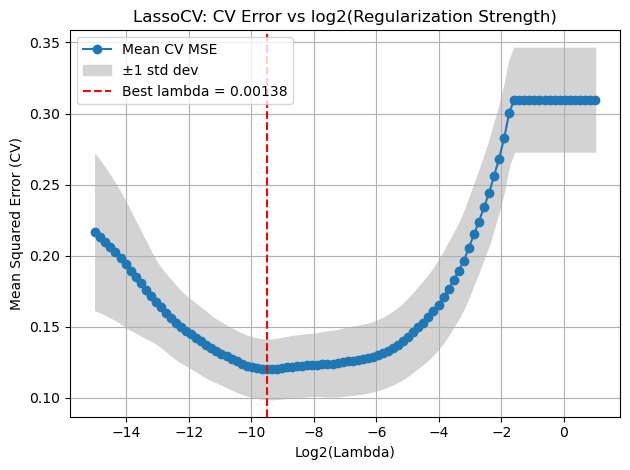


Best Lasso regularization parameter: 0.0013762416204132462


Nb of selected variables: 318


Training R2:  0.7318



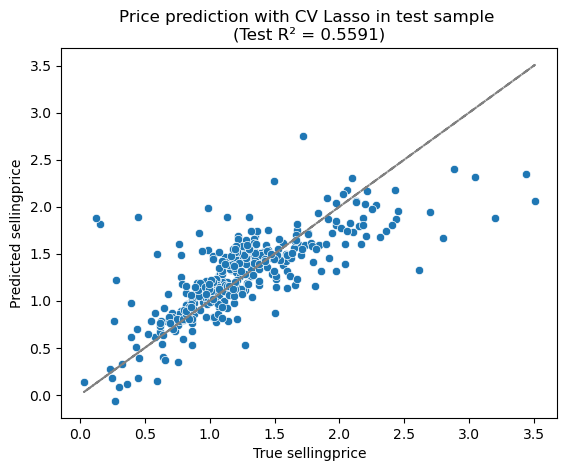

In [63]:
# CV Lasso regression with sklearn LassoCV

lambda_chosen, coefs, Y_train_pred, Y_test_pred = CV_Lasso_from_sklearn(
    X_train, X_test, Y_train, Y_test, nb_cores=5
)

print(f"\nBest Lasso regularization parameter: {lambda_chosen}\n")

print(f"\nNb of selected variables: {(coefs!=0).sum().iloc[0]-1}\n")

selected_vars_for_price_eq = list(coefs.iloc[1:,0][coefs.iloc[1:,0]!=0].index)

print(f"\nTraining R2: {r2_score(Y_train, Y_train_pred): .4f}\n")

plot_true_predicted(Y_test, Y_test_pred, VarName=Y_train.name)


In [64]:
with pd.option_context('display.max_rows', 100):
    print(coefs)

                                                Coefs
(Intercept)                                  1.224553
odometer                                    -0.131533
condition                                    0.079191
year_1999                                   -0.021557
year_2000                                   -0.042824
...                                               ...
interior_gray*interior_other_RivalProducts   0.000000
interior_gray*interior_tan_RivalProducts     0.000000
interior_other*interior_other_RivalProducts  0.006867
interior_other*interior_tan_RivalProducts   -0.000000
interior_tan*interior_tan_RivalProducts      0.006378

[779 rows x 1 columns]


---
### Régression Lasso de l'équation du prix (2) et sélection des variables grâce à la commande glmnet du logiciel R

R[write to console]: Loading required package: Matrix

R[write to console]: Loaded glmnet 4.1-8

R[write to console]: Loading required package: foreach

R[write to console]: Loading required package: iterators

R[write to console]: Loading required package: parallel



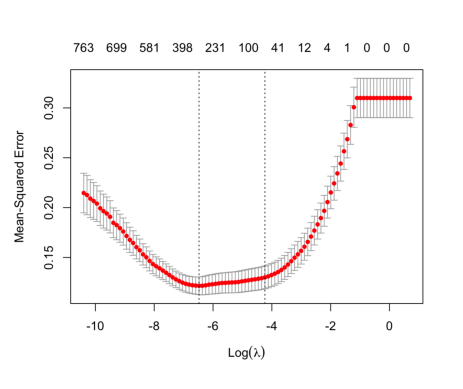


Best Lasso regularization parameter: [0.00153938]


Nb of selected variables: 308


Training R2:  0.7246



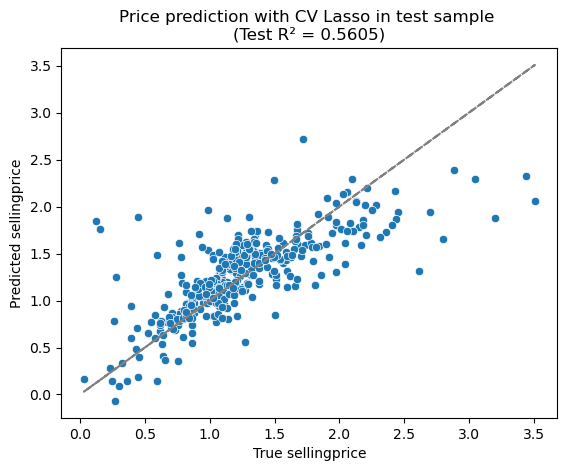

In [66]:
# CV Lasso regression with R glmnet

lambda_chosen,  coefs, Y_train_pred, Y_test_pred = CV_Lasso_from_R_glmnet(
    X_train, X_test, Y_train, Y_test, nb_cores=5
)

print(f"\nBest Lasso regularization parameter: {lambda_chosen}\n")

print(f"\nNb of selected variables: {(coefs!=0).sum().iloc[0]-1}\n")

selected_vars_for_price_eq = list(coefs.iloc[1:,0][coefs.iloc[1:,0]!=0].index)

print(f"\nTraining R2: {r2_score(Y_train, Y_train_pred): .4f}\n")

plot_true_predicted(Y_test, Y_test_pred, VarName=Y_train.name)


In [67]:
with pd.option_context('display.max_rows', 100):
    print(coefs)

                                                Coefs
(Intercept)                                  1.724783
odometer                                    -0.042331
condition                                    0.012395
year_1999                                   -0.328544
year_2000                                   -1.053710
...                                               ...
interior_gray*interior_other_RivalProducts   0.000000
interior_gray*interior_tan_RivalProducts     0.000000
interior_other*interior_other_RivalProducts  0.033222
interior_other*interior_tan_RivalProducts    0.000000
interior_tan*interior_tan_RivalProducts      0.000000

[779 rows x 1 columns]


---
### Régression de la demande après remplacement du prix par sa prédiction exogène obtenue par regression Lasso


In [69]:
import scipy.stats as stats

def ratio_coefs_pvalue(var1, var2, params, cov):

    if var1==var2:
        pvalue=0
    else:
        # Compute the ratio and its standard error using the Delta Method
        a = params[var1]
        b = params[var2]
        var_a = cov.loc[var1, var1]
        var_b = cov.loc[var2, var2]
        cov_ab = cov.loc[var1, var2]    
        ratio = a / b
        var_ratio = (1 / b**2) * var_a + (a**2 / b**4) * var_b - (2 * a / b**3) * cov_ab
        se_ratio = var_ratio**0.5
    
        #  Compute the z-statistic and p-value
        
        z = (ratio - 1) / se_ratio  # Test if ratio == 1
        pvalue = 2 * (1 - stats.norm.cdf(abs(z)))

    return pvalue

In [70]:
def regress_demand(X_train, Y_train, price_train_predicted=None):

    X_train_new = X_train.copy()

    if ~np.all(price_train_predicted==None):
        X_train_new[price_train_predicted.name] = price_train_predicted

    model = sm.OLS(Y_train, sm.add_constant(X_train_new)).fit()

    #print(model.summary())

    Y_train_pred = model.predict(sm.add_constant(X_train_new))

    coefs = model.params

    cov = model.cov_params()

    WTP_pvalue = pd.Series(
        model.params.index.map(lambda var1: ratio_coefs_pvalue(var1, 'sellingprice', coefs, cov)), 
        index=model.params.index
    )

    # Merge coefs, WTP (willingness to pay) and their pvalues
    coefs = pd.concat([coefs, model.pvalues,  coefs/np.abs(coefs['sellingprice']), WTP_pvalue], axis=1)
    coefs.columns = ['coef','coef-pvalue','wtp','wtp-pvalue']
 
    return model, coefs, Y_train_pred
    

In [71]:
def plot_coefs(coef_series, pvalue_series, titlename):

    # pvalue_stars
    pvalue_stars_series = pvalue_series.map(
        lambda x: '****' if x<0.001 else ('***' if x<0.01 else ('  **' if x<0.05 else ('   *' if x<0.1 else '      ')))
    )

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Plot the bars with color based on value
    bars = ax.bar(coef_series.index, [0.1 if v>=0 else -0.1 for v in coef_series],  # All bars have the same length
                  color=['#4c72b0' if v >= 0 else '#c44e52' for v in coef_series])
    
    # Add true value labels on top of the bars
    ax.bar_label(
        bars, labels=[f'{coef_series[name]:.3f} {pvalue_stars_series[name]}' for name in coef_series.index],
        padding=3, fontsize=10, rotation=90
    )
    
    # Add title and labels
    ax.set_title(f"{titlename} \n\n(****: pvalue < 0.001, ***: pvalue < 0.01, **: pvalue < 0.05, *: pvalue < 0.1)\n")
    ax.set_xlabel("Product Attribute")
    ax.set_ylabel("")
    ax.axhline(0, color='black', linewidth=0.8)
    
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=90)
    
    # Remove y ticks
    ax.set_yticks([])
    
    ax.set_ylim((-.22,.22))
    
    # Adjust layout to prevent clipping
    plt.tight_layout()
    
    plt.show()


In [72]:
price_train_predicted = Y_train_pred.copy()

model, coefs, _ = regress_demand(data_train[endogvars+exogvars], data_train[depvars[-1]], price_train_predicted)


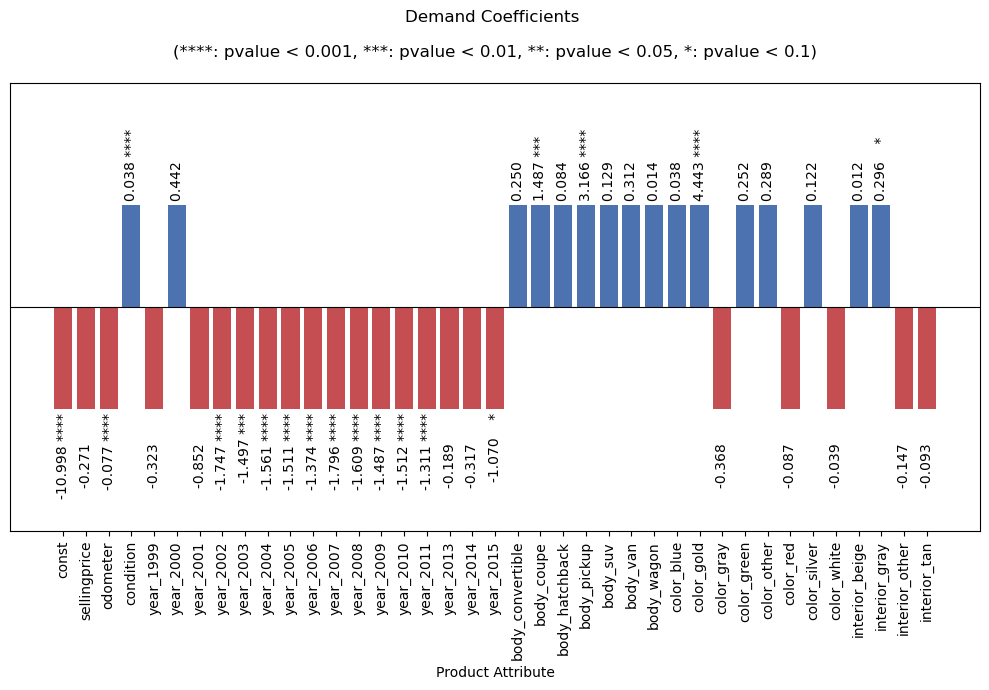

In [73]:
plot_coefs(coefs['coef'], coefs['coef-pvalue'], "Demand Coefficients")

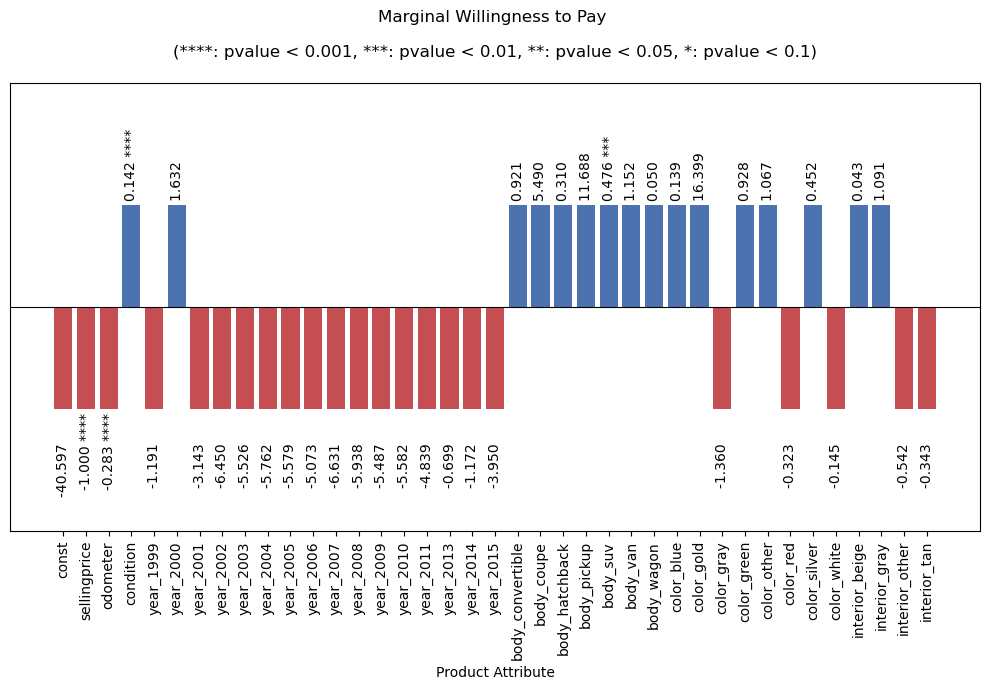

In [74]:
plot_coefs(coefs['wtp'], coefs['wtp-pvalue'], "Marginal Willingness to Pay")

---
---
# Approximation flexible de $E[P_{jt}|X_{t},Z_{jt}]$ pour relâcher l'hypothèse de linéarité

Les variables contenues dans $X_t$ et $Z_{jt}$ peuvent être utilisées comme instruments pour le prix — c’est-à-dire qu’elles aident à isoler la partie du prix qui n’est pas influencée par la demande. Parmi elles, les variables dans $Z_{jt}$ sont dites exclues de l’équation de demande : elles influencent le prix mais pas directement la demande. Toute fonction construite à partir de ces variables peut donc aussi servir d’instrument. En particulier, la fonction $E[P_{jt} \mid X_t, Z_{jt}]$ — qui correspond à la meilleure prédiction possible du prix à partir de $X_t$ et $Z_{jt}$ — est un instrument particulièrement efficace. Elle capte toute l’information sur le prix que l’on peut extraire de ces variables.

Pour approximer cette fonction de manière flexible, nous allons utiliser deux méthodes issues de l’apprentissage automatique : les forêts aléatoires (random forest) et les réseaux de neurones profonds (deep neural networks).

In [113]:
def random_forest(X_train, X_test, Y_train, Y_test, nb_cores=3, max_vars_per_tree=1.0):

    # Initialize Random Forest Regressor
    rf = RandomForestRegressor(n_estimators=200, random_state=42, max_features=max_vars_per_tree, n_jobs=nb_cores)

    # Cross-validation scores (R² by default)
    cv_scores = cross_val_score(rf, X_train, Y_train, cv=5, scoring='r2', n_jobs=nb_cores)

    # Cross-validated predictions
    Y_train_pred = cross_val_predict(rf, X_train, Y_train, cv=5, n_jobs=nb_cores)
    Y_test_pred = cross_val_predict(rf, X_test, Y_test, cv=5, n_jobs=nb_cores)

    Y_train_pred = pd.Series(Y_train_pred, name=Y_train.name)
    Y_test_pred = pd.Series(Y_test_pred, name=Y_test.name)

    return Y_train_pred, Y_test_pred


In [115]:
def deep_nn(X_train, X_test, Y_train, Y_test, loss='mae', hiden_layer_size=None):
    
    scaler = StandardScaler().fit(X_train)
    X_train_1 = pd.DataFrame(scaler.transform(X_train), index = X_train.index, columns=X_train.columns)
    X_test_1 = pd.DataFrame(scaler.transform(X_test), index = X_test.index, columns=X_test.columns)

    nnmodel = keras.Sequential([
        Input(shape=(X_train.shape[1],)),
        layers.Dense(hiden_layer_size, activation='relu'),
        layers.Dense(hiden_layer_size, activation='relu'),
        layers.Dense(hiden_layer_size, activation='relu'),
        layers.Dense(hiden_layer_size, activation='relu'),
        layers.Dense(1)])
    nnmodel.compile(optimizer='adam',
                  loss=loss,       # Mean Absolute Error for regression (is more robust to outliers, but slower)
                  metrics=['mse']   # Mean Squared Error for evaluation
                 )
    
    print(nnmodel.summary())

    nnmodel.fit(X_train_1, Y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=False)

    Y_train_pred = pd.Series(nnmodel.predict(X_train_1)[:,0], name=Y_train.name)
    Y_test_pred = pd.Series(nnmodel.predict(X_test_1)[:,0], name=Y_test.name)

    return Y_train_pred, Y_test_pred 


---
### Fôrets aléatoires utilisant toutes les variables de l'équation du prix

Donner au paramètre $max\_vars\_per\_tree$  la même valeur que le nombre de variables précédemment sélectionnées par la régression linéaire Lasso


Training R2:  0.6177



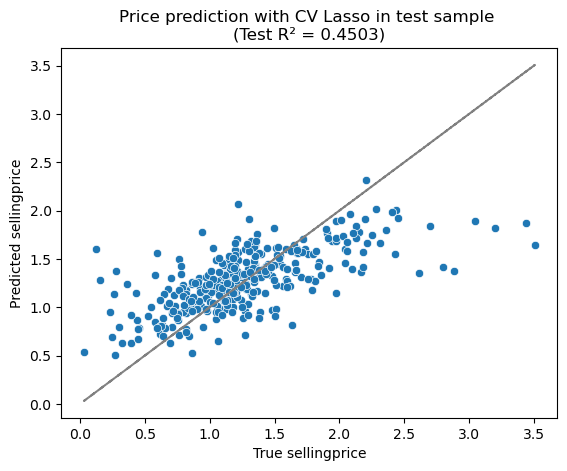

In [79]:
X_train = data_train[exogvars+instrvars]

X_test = data_test[exogvars+instrvars]

Y_train = data_train[endogvars[0]]

Y_test = data_test[endogvars[0]]

Y_train_pred, Y_test_pred = random_forest(X_train, X_test, Y_train, Y_test, nb_cores=5, max_vars_per_tree=len(selected_vars_for_price_eq))

print(f"\nTraining R2: {r2_score(Y_train, Y_train_pred): .4f}\n")

plot_true_predicted(Y_test, Y_test_pred, VarName=Y_train.name)

---
### Random Forests using only variables that were selected previously from Lasso linear regression

Donner au paramètre $max\_vars\_per\_tree$ la valeur $1.0$ pour que toutes les variables dans $X_train$ soient utiliser.


Training R2:  0.6315



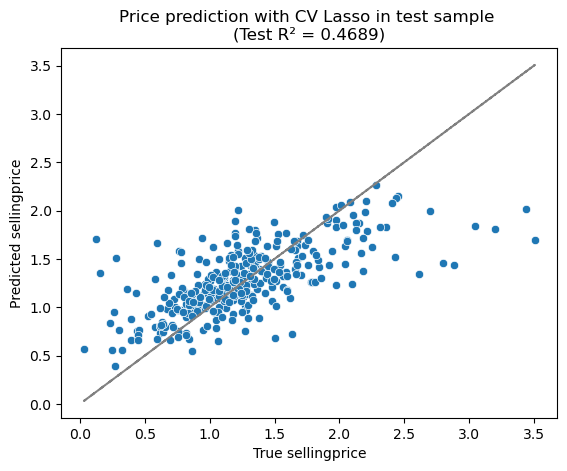

In [118]:
X_train = data_train[selected_vars_for_price_eq]

X_test = data_test[selected_vars_for_price_eq]

Y_train = data_train[endogvars[0]]

Y_test = data_test[endogvars[0]]

Y_train_pred, Y_test_pred = random_forest(X_train, X_test, Y_train, Y_test, nb_cores=5, max_vars_per_tree=1.0)

print(f"\nTraining R2: {r2_score(Y_train, Y_train_pred): .4f}\n")

plot_true_predicted(Y_test, Y_test_pred, VarName=Y_train.name)

---
### Régression de la demande après remplacement du prix par sa prédiction exogène obtenue par forêts aléatoires


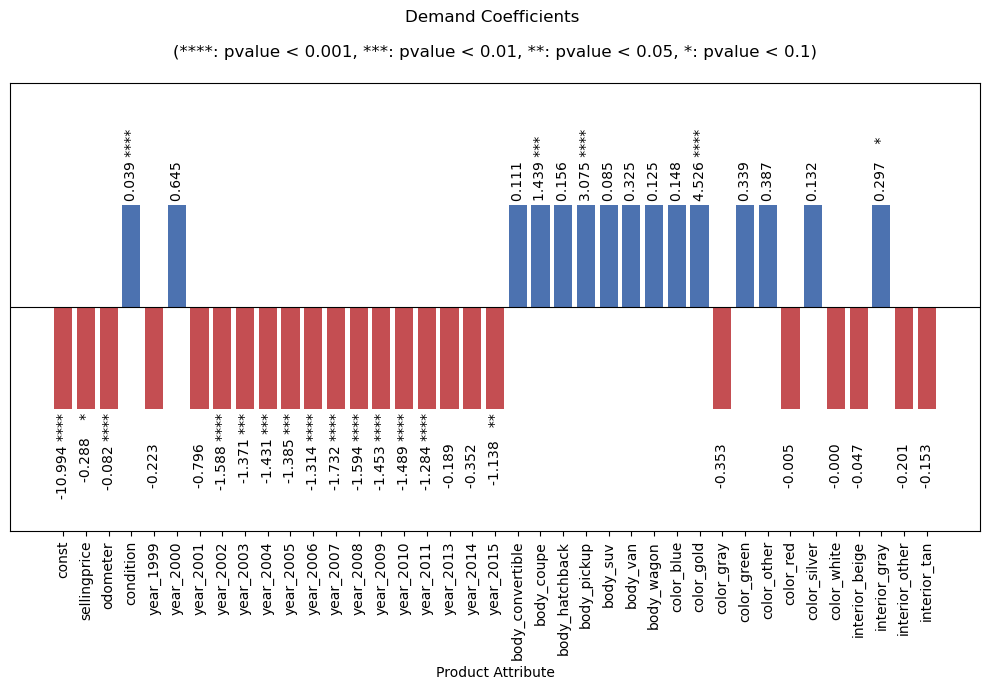

In [120]:
price_train_predicted = Y_train_pred.copy()

model, coefs, _ = regress_demand(data_train[endogvars+exogvars], data_train[depvars[-1]], price_train_predicted)

plot_coefs(coefs['coef'], coefs['coef-pvalue'], "Demand Coefficients")

---
### Deep Neural Network using all variables in the price equations 

Set the "output shape" parameter for hidden layers as same as the number of previously selected variables from Lasso linear regression

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 308)            │       239,932 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 308)            │        95,172 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 308)            │        95,172 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 308)            │        95,172 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           309 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,757 (2.01 MB)

 Trainable params: 525,757 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

None
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Training R2:  0.9361



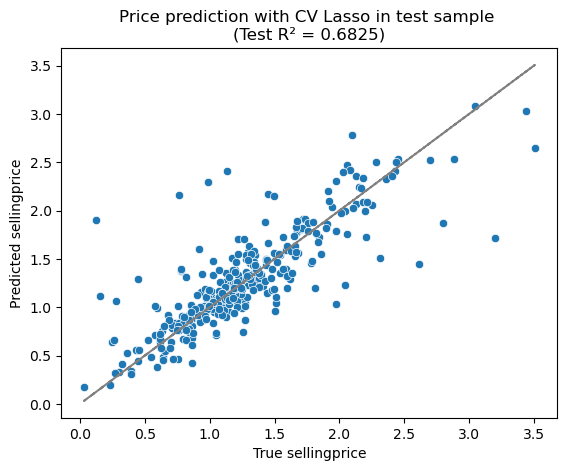

In [83]:
X_train = data_train[exogvars+instrvars]

X_test = data_test[exogvars+instrvars]

Y_train = data_train[endogvars[0]]

Y_test = data_test[endogvars[0]]

Y_train_pred, Y_test_pred = deep_nn(X_train, X_test, Y_train, Y_test, loss='mse', hiden_layer_size=len(selected_vars_for_price_eq))

print(f"\nTraining R2: {r2_score(Y_train, Y_train_pred): .4f}\n")

plot_true_predicted(Y_test, Y_test_pred, VarName=Y_train.name)

---
### Deep Neural Network using only variables that were selected previously from Lasso linear regression

Set the "output shape" parameter as same as the number of variables in input


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 308)            │        95,172 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 308)            │        95,172 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 308)            │        95,172 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 308)            │        95,172 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           309 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,997 (1.45 MB)

 Trainable params: 380,997 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

None
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Training R2:  0.9358



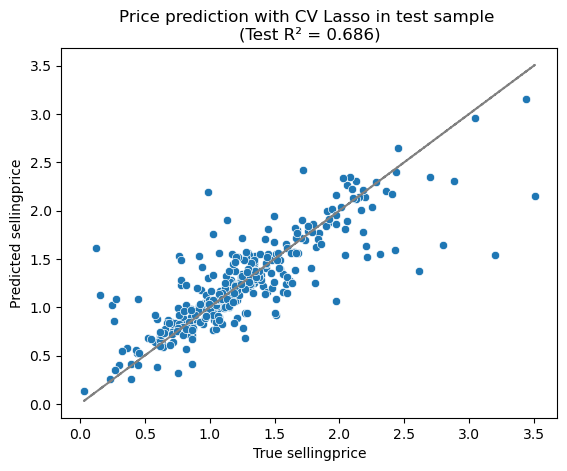

In [93]:
X_train = data_train[selected_vars_for_price_eq]

X_test = data_test[selected_vars_for_price_eq]

Y_train = data_train[endogvars[0]]

Y_test = data_test[endogvars[0]]

Y_train_pred, Y_test_pred = deep_nn(X_train, X_test, Y_train, Y_test, loss='mse', hiden_layer_size=len(selected_vars_for_price_eq))

print(f"\nTraining R2: {r2_score(Y_train, Y_train_pred): .4f}\n")

plot_true_predicted(Y_test, Y_test_pred, VarName=Y_train.name)


---
### Régression de la demande après remplacement du prix par sa prédiction exogène obtenue par réseau de neuronne


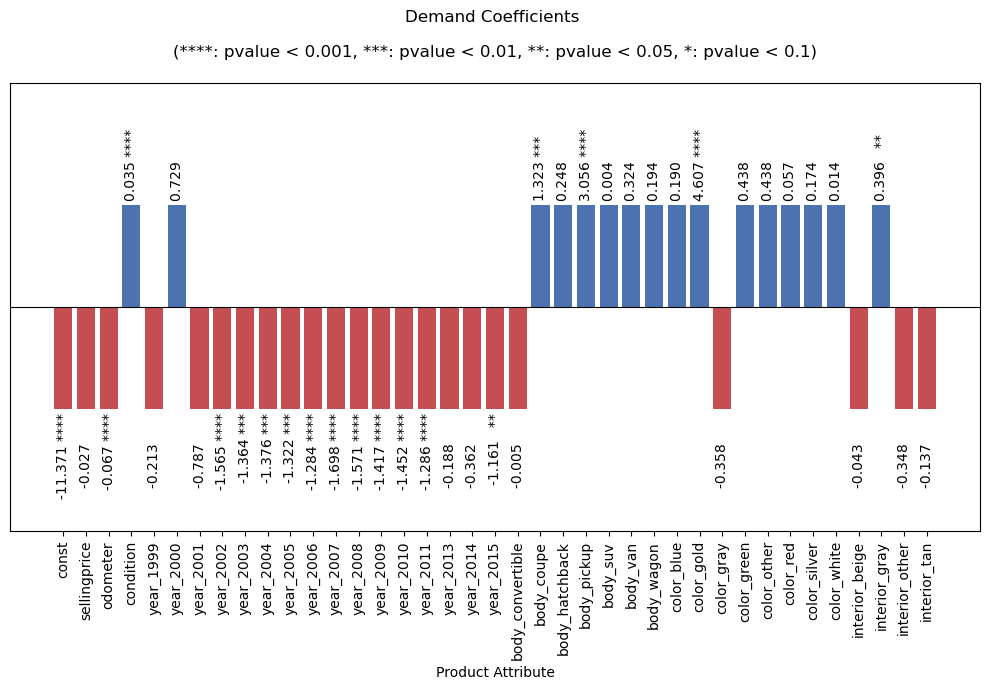

In [91]:
price_train_predicted = Y_train_pred.copy()

model, coefs, _ = regress_demand(data_train[endogvars+exogvars], data_train[depvars[-1]], price_train_predicted)

plot_coefs(coefs['coef'], coefs['coef-pvalue'], "Demand Coefficients")

---
---
# Réduction de dimension des predicteurs du prix: Analyse en Composantes Principales, ACP (PCA en anglais)

On applique l'ACP pour reduire la dimension des predicteurs du prix. La réduction du nombre de variables pourrait nous donner plus de flexibilité dans la prediction du prix.


Soit $U$ la matrice des prédicteurs du prix (par exemple les variables $X$ et $Z$). L'analyse en composantes principales (ACP) consiste à trouver une matrice orthonormée $P$ telle que $V = UP$ soit une transformation linéaire de $U$ vers un nouvel espace dans lequel les composantes sont non corrélées et ordonnées par variance décroissante.

La matrice $V$ est appelée matrice des composantes principales. Si l'on conserve les $v$ premières colonnes de $V$, on obtient une approximation de $U$ dans un espace de dimension réduite qui préserve le plus possible la variance initiale. Cette approximation est optimale au sens où aucune autre combinaison linéaire de $v$ composantes ne permet de conserver davantage de variance.

### Reduison  l'espace des predicteurs du prix à travers l'ACP

In [ ]:

# Step 1: Standardize the features
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(data_train[exogvars+instrvars])
X_scaled_test = scaler.fit_transform(data_test[exogvars+instrvars])

# Step 2: Apply PCA
pca = PCA(n_components=X_scaled_train.shape[1])
X_pca_train = pca.fit_transform(X_scaled_train)
X_pca_test = pca.transform(X_scaled_test)

# Step 3: View results
y=pca.explained_variance_ratio_; x=np.arange(len(pca.explained_variance_ratio_))


fig, ax = plt.subplots()
# First plot on left y-axis
line1 = sns.lineplot(x=x, y=y, ax=ax, label='Explained variance ratio')
ax.set_xlabel('Component index')
# Second plot on right y-axis
ax2 = ax.twinx()
line2 = sns.lineplot(x=x, y=y.cumsum(), linestyle='--', ax=ax2, label='Cumulative explained variance ratio')
# Combine line handles and labels
lines, labels = [], []
for axis in [ax, ax2]:
    line_objs, label_list = axis.get_legend_handles_labels()
    lines.extend(line_objs)
    labels.extend(label_list)
# Add combined legend to ax
ax.legend(lines, labels, loc='right')
ax2.legend(lines, labels, loc='right')
plt.title("Explained Variance and Cumulative Variance")
plt.show()

In [ ]:
X_pca_train = pca.transform(X_scaled_train)[:,:200]; Y_train = data_train[endogvars[0]]
X_pca_test = pca.transform(X_scaled_test)[:,:200]; Y_test = data_test[endogvars[0]]


 

nnmodel = keras.Sequential([
    Input(shape=(X_pca_train.shape[1],)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    layers.Dense(1)])
nnmodel.compile(optimizer='adam',
              loss='mae',               # Mean absolute Error for regression (is more robust to outliers)
              metrics=['mse']         # Mean Squared Error for evaluation
             )

print(nnmodel.summary())

nnmodel.fit(X_pca_train, Y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=False)



In [ ]:
##Predictions from Neural Network
price_pred_train = nnmodel.predict(X_pca_train)[:,0]
price_pred_test = nnmodel.predict(X_pca_test)[:,0]
r2_train = 1-(sum((Y_train-price_pred_train)**2)/sum((Y_train-np.mean(Y_train))**2))
r2_test = 1-(sum((Y_test-price_pred_test)**2)/sum((Y_test-np.mean(Y_test))**2))
sns.scatterplot(x=Y_test,y=price_pred_test)
plt.plot(Y_test, Y_test, linestyle='--', color='gray')
plt.xlabel("sellingprice"); plt.ylabel("Predicted sellingprice")
plt.title(f"Price prediction with deep neural network in test sample (r2 = {round(r2_test,4)})")

### Estimons l'equation (3) de la demande en utilisant les prediction precedente des prix.

In [ ]:
explan_data_train = pd.concat([pd.Series(price_pred_train, name=endogvars[0]),data_train[exogvars]],axis=1)
explan_data_test = pd.concat([pd.Series(price_pred_test, name=endogvars[0]),data_test[exogvars]],axis=1)
dep_data_train = data_train[depvars[-1]]; dep_data_test = data_test[depvars[-1]]

iv2sls_with_lasso_model = sm.OLS(data_train[depvars[-1]], sm.add_constant(explan_data_train)).fit()
print(iv2sls_with_lasso_model.summary())

# Imputation des valeurs manquantes; en utilisant l'imputation multivariee par equations chainees (Multivariate Imputation by Chained Equations, MICE) du logiciel R

Nous allons faire un exercice d'imputation des valeurs manquantes de notre base de donnees en estimant des equations de prediction des variables ayant des valeurs manquantes. 

L'hypothese principale sur laquelle repose la procedure MICE est l'hypothese 'Missing At Random' (MAT). Autrement dit, on suppose que les valeurs manquantes surviennent de facon aleatoire dans les donnees.

Supposons une base de donnees avec trois variables A, B et C, la variable C n'ayant pas de valeurs manquantes. La procedure MICE s'applique de la facon suivante:

- iteration 0: commencer par une simple imputation univariee en ramplacant les valeurs manquantes de A et B par une statistique de tendance centrale (mode, moyenne, mediane). Mettre a jour les valeurs de A et B.
- iteration i = 1, ..., maxit:
    - regresser A sur B et C, avec les valeurs a jour de B. Predire les valeurs des donnees manquantes de A a partir de cette regression. Mettre les valeurs de A a jour.
    - regresser B sur A et C, avec les valeurs a jour de A. Predire les valeurs des donnees manquantes de B a partir de cette regression. Mettre les valeurs de B a jour.
 
Cet algorithme permet d'effectuer une imputation par equations chainees. Afin de prendre en compte l'incertitude creee par les valeurs manquantes, plusieurs imputations vont etre effectuees dans la procedure MICE. Autrement dit, plusieurs bases de donnees completees vont etre generees. Dans notre cas, nous allons retourner une seule imputation.


Les méthodes par défaut pour estimer les equations chainees sont les suivantes :

- l’appariement sur la moyenne prédictive (predictive mean matching – pmm) pour les données numériques
- l’imputation par régression logistique (logistic regression imputation – logreg) pour les données binaires
- l’imputation par régression polytomique (polytomous regression imputation – polyreg) pour les variables qualitatives à niveaux non ordonnés
- le modèle des rapports proportionnels (proportional odds model – polr) pour les variables qualitatives à niveaux ordonnés.

Nous n'allons pas utiliser ces methodes par defaut. A la place, nous allons utiliser une methode de Machine learning, en l'occurance 

In [ ]:
#import the car sales and population size datasets
cars_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/car_prices.csv'
population_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/states_populations_yr2015.csv'
df = load_data(cars_file_path); pop_df = load_data(population_file_path) #.drop('population (2015)', axis=1)
df = process_dates(df)
df = define_market(df, market_vars=['sellingyear','sellingmonth','state'], market_label='market', market_code='marketid', minsize=20, DropSmallMarkets=True)
df =  preprocess_color_interior(df)
df = subset_var_of_interest(df, var_of_interest=numerical_vars+['state']+unordered_vars, marketvar='marketid', productvar='make', DropNa=False)
df = change_to_numerical(df, numerical_vars)
df = order_unorder_categorical_var(
    df, ordered=[], unordered=unordered_vars, ordered_masks=dict(), unordered_masks=unordered_masks, 
    ordered_min_frequencies=dict(), unordered_min_frequencies=unordered_minfreq
)


In [ ]:
#_, df_to_impute = train_test_split(df.drop('marketid',axis=1), test_size=20000, random_state=42)
df_to_impute = df.drop('marketid',axis=1).copy()

In [ ]:
#A view of the dataframe to impute
df_to_impute

In [ ]:
#Missing values in the dataframe to impute
df_to_impute.isna().sum(axis=0)

In [ ]:
CompleteNumericalVars = ['sellingprice']; CompleteUnorderedVars = ['year']
IncompleteNumericalVars = ['odometer', 'condition']; IncompleteOrderedVars = None; IncompleteUnorderedVars = ['make','body','color','interior']
df_to_impute['saleid'] = df_to_impute.index


In [ ]:
%load_ext rpy2.ipython

In [ ]:

%%R -i df_to_impute  -o imputed_df

library(readr)
library(mice)
library(dplyr)
library(parallel)
library(doParallel)

CompleteNumericalVars = c('sellingprice'); CompleteUnorderedVars = c('year', 'state')
IncompleteNumericalVars = c('odometer', 'condition'); IncompleteOrderedVars = NULL; IncompleteUnorderedVars = c('make','body','color','interior')

df <- df_to_impute
#df <- select(df, -state)

if (('saleid' %in% colnames(df))==FALSE){
  df$saleid <- seq(nrow(df))
}


for (var in colnames(df)){
  if (var %in% IncompleteOrderedVars){
    df[,var] <- factor(as.integer(df[,var]), ordered=TRUE)
  }
  if (var %in% c(CompleteUnorderedVars, IncompleteUnorderedVars)){
    df[,var] <- factor(df[,var], ordered=FALSE)
  }
}


#The dataset is too heavy. For now, focus on incomlete rows, plus few additional rows (if incomplete rows are less than 100K).
incompleteness_filter <- !complete.cases(df)
complete_df <- df[!incompleteness_filter,]
nb_incomplete_rows <- sum(incompleteness_filter)
if (nb_incomplete_rows<=100000){
  sampled_rows <- sample_n(complete_df, 100000-nb_incomplete_rows)
  sampled_rows_filter <- df$saleid %in% sampled_rows$saleid
  final_filter <- incompleteness_filter | sampled_rows_filter
} else {
  final_filter <- incompleteness_filter
}

imputer <- futuremice(
  data=select(df[final_filter,], -saleid),
  blocks=list(IncompleteUnorderedVars, IncompleteNumericalVars, c(CompleteNumericalVars, CompleteUnorderedVars )), 
  method=c("rf","rf", ""), #I would've used random forests ('rf','rf','rf') if there was not computation issue
  m=10, maxit=10, #default m=5, default maxit=5
  parallelseed = 123, print = FALSE, n.core = 5
)

imputed_df <- complete(imputer)

imputed_df <- cbind(df[final_filter,'saleid'], imputed_df)
colnames(imputed_df)[1] <- 'saleid'
imputed_df <- rbind(imputed_df,df[!final_filter,])
#imputed_df <- NULL


In [ ]:
#There are no missing values in the imputed dataframe
imputed_df.isna().sum(axis=0)

In [ ]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 7))

vars = ['odometer','condition']

i = 0
for i in range(len(vars)):
    var = vars[i]
    
    incompleteness_filter = df_to_impute[var].isna()
    incompleteness_IDs = df_to_impute[incompleteness_filter]['saleid']
    observed_and_imputed_values = imputed_df[var]
    observed_values = df_to_impute[var][~incompleteness_filter]
    imputed_values = imputed_df[var][imputed_df['saleid'].isin(incompleteness_IDs)]

    ax=plt.subplot(1,2,i+1)
    sns.histplot(observed_and_imputed_values, color='green', label='Both observed and imputed values', kde=True, stat='density', bins=30)
    sns.histplot(observed_values, color='blue', label='Observed values', kde=True, stat='density', bins=50, alpha=0.6)
    sns.histplot(imputed_values, color='orange', label='Imputed missing values', kde=True, stat='density', bins=50, alpha=0.3)
    plt.xticks(rotation=45)
    plt.title(var)
    plt.legend()
    plt.xlabel("Value")
    plt.ylabel("Density")
plt.show()

In [ ]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 15))

vars = [['make','body'],['color','interior']]

i = 0
for i1 in range(2):
    for i2 in range(2):
        var = vars[i1][i2]
        incompleteness_filter = df_to_impute[var].isna()
        incompleteness_IDs = df_to_impute[incompleteness_filter]['saleid']
        observed_and_imputed_values = imputed_df[var]
        observed_values = df_to_impute[var][~incompleteness_filter]
        imputed_values = imputed_df[var][imputed_df['saleid'].isin(incompleteness_IDs)]
        
        # Ensure same category order
        categories = sorted(set(observed_values.unique()) | set(imputed_values.unique()) | set(observed_and_imputed_values.unique()))
        
        # Compute value frequencies, reindexed to have same order
        freq_observed_and_imputed = observed_and_imputed_values.value_counts().reindex(categories, fill_value=0)/len(observed_and_imputed_values)
        freq_observed = observed_values.value_counts().reindex(categories, fill_value=0)/len(observed_values)
        freq_imputed = imputed_values.value_counts().reindex(categories, fill_value=0)/len(imputed_values)
        
        # Plot side-by-side bars
        x = range(len(categories))
        width = 0.35
        
        i = i+1
        ax=plt.subplot(2,2,i)
        plt.bar([j - 2*width/3 for j in x], freq_observed_and_imputed, width=width, color='green', label='Both observed and imputed values')
        plt.bar([j - width/3 for j in x], freq_observed, width=width, color='blue', alpha=0.6, label='Observed values')
        plt.bar([j + width/3 for j in x], freq_imputed, width=width, color='orange', alpha=0.3, label='Imputed missing values')
        plt.xticks(ticks=x, labels=categories)
        plt.xlabel("Category")
        plt.ylabel("Frequency")
        plt.title(var)
        plt.legend()
        plt.tight_layout()
        plt.xticks(rotation=45)

plt.show()

In [ ]:
# If we want to customize the random forest parameters inside the MICE procedure, and if we want to get the prediction performances, 
# we can define:
"""
mice.impute.rf_custom <- function(y, ry, x, wy = NULL, ...) {
  require(randomForest)
  rf <- randomForest(x[ry, ], y[ry], ntree = 500, mtry = 4)  # ← your custom settings
  preds <- predict(rf, newdata = x[!ry, ])

  # Evaluate performance (on training set or via OOB)
  y_train <- y[ry]
  y_pred_train <- predict(rf, newdata = x[ry, ])
  mse <- mean((y_pred_train - y_train)^2)
  cat("RF training MSE:", round(mse, 3), "\n")

  return(preds)
}

then set method = "rf_custom" for the columns to be imputed using random forests.
"""

# Detection et remplacement des valeurs aberrantes par AutoEncodeur (une application du deep learning)


In [ ]:
#Set the df used to check for anomalies
df_for_anomalies = imputed_df.drop('saleid',axis=1)
#Standardize numerical columns
df_numeric_mean = df_for_anomalies[['sellingprice','odometer','condition']].mean(axis=0)
df_numeric_std = df_for_anomalies[['sellingprice','odometer','condition']].std(axis=0)
df_for_anomalies[['sellingprice','odometer','condition']] = (df_for_anomalies[['sellingprice','odometer','condition']]-df_numeric_mean)/df_numeric_std
# Split the data
X_numeric = df_for_anomalies[['sellingprice','odometer','condition']]
X_state = pd.get_dummies(df_for_anomalies[['state']]); X_year = pd.get_dummies(df_for_anomalies[['year']])
X_make = pd.get_dummies(df_for_anomalies[['make']]); X_body = pd.get_dummies(df_for_anomalies[['body']])
X_color = pd.get_dummies(df_for_anomalies[['color']]); X_interior = pd.get_dummies(df_for_anomalies[['interior']])
df_for_anomalies_train, df_for_anomalies_test, X_numeric_train,  X_numeric_test, X_state_train, X_state_test, X_year_train, X_year_test,  X_make_train, X_make_test, X_body_train, X_body_test, X_color_train, X_color_test, X_interior_train, X_interior_test = train_test_split(
    df_for_anomalies, X_numeric, X_state, X_year, X_make, X_body, X_color, X_interior, test_size=0.1, random_state=42
)

X_list_train = [X_numeric_train, X_state_train, X_year_train, X_make_train, X_body_train, X_color_train, X_interior_train]
X_list_test = [X_numeric_test, X_state_test, X_year_test, X_make_test, X_body_test, X_color_test, X_interior_test]

X_train = pd.concat(X_list_train, axis=1)
X_test = pd.concat(X_list_test, axis=1)

#X_train, X_test = train_test_split(X, test_size=0.1, random_state=42)
#X.head()

X_train.shape, X_test.shape

In [ ]:
X_numeric_train.shape,  X_numeric_test.shape, X_state_train.shape, X_state_test.shape

In [ ]:
#count levels for the categorical columns
for var in ['state','year','make','body','color','interior']:
    print(f"Column {var} has {len(imputed_df[var].unique())} levels")

In [ ]:
# Input
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(50, activation='relu')(input_layer)
encoded = Dense(20, activation='relu')(encoded)
encoded = Dense(10, activation='relu')(encoded)

# Decoder for numerical columns (e.g., 3 continuous values)
numerical_output = Dense(X_numeric_train.shape[1], activation='linear', name='numerical_output')(encoded)

# Decoder for categorical columns ('state','year','make','body','color','interior'), each with nb of dummies (38, 17, 17, 8, 9, 5)
categorical_output_state = Dense(X_state_train.shape[1], activation='softmax', name='categorical_output_state')(encoded)
categorical_output_year = Dense(X_year_train.shape[1], activation='softmax', name='categorical_output_year')(encoded)
categorical_output_make = Dense(X_make_train.shape[1], activation='softmax', name='categorical_output_make')(encoded)
categorical_output_body = Dense(X_body_train.shape[1], activation='softmax', name='categorical_output_body')(encoded)
categorical_output_color = Dense(X_color_train.shape[1], activation='softmax', name='categorical_output_color')(encoded)
categorical_output_interior = Dense(X_interior_train.shape[1], activation='softmax', name='categorical_output_interior')(encoded)

# Model with multiple outputs
autoencoder = Model(
    inputs=input_layer, 
    outputs=[numerical_output, categorical_output_state, categorical_output_year, categorical_output_make, 
             categorical_output_body, categorical_output_color, categorical_output_interior]
)

# Compile with multiple loss functions
autoencoder.compile(optimizer='adam',
                    loss={
                        'numerical_output': 'mae',
                        'categorical_output_state': 'categorical_crossentropy',
                        'categorical_output_year': 'categorical_crossentropy',
                        'categorical_output_make': 'categorical_crossentropy',
                        'categorical_output_body': 'categorical_crossentropy',
                        'categorical_output_color': 'categorical_crossentropy',
                        'categorical_output_interior': 'categorical_crossentropy',
                    },
                    loss_weights={
                        'numerical_output': 1.0,
                        'categorical_output_state': 1.0,
                        'categorical_output_year': 1.0,
                        'categorical_output_make': 1.0,
                        'categorical_output_body': 1.0,
                        'categorical_output_color': 1.0,
                        'categorical_output_interior': 1.0
                    })

autoencoder.summary()

# Fit the model
history = autoencoder.fit(
    X_train, [X_numeric_train, X_state_train, X_year_train, X_make_train, X_body_train, X_color_train, X_interior_train], 
    epochs=100, batch_size=1000, validation_split=0.2, verbose=False
)



In [ ]:
X_list_train_predict =  autoencoder.predict(X_train)
X_numeric_train_predict, X_state_train_predict, X_year_train_predict, X_make_train_predict, X_body_train_predict, \
X_color_train_predict, X_interior_train_predict = X_list_train_predict

X_list_test_predict =  autoencoder.predict(X_test)
X_numeric_test_predict, X_state_test_predict, X_year_test_predict, X_make_test_predict, X_body_test_predict, \
X_color_test_predict, X_interior_test_predict = X_list_test_predict

In [ ]:
## Reconstruct the input datasets
def reconstruct_columns(y_true, y_pred, numerical=True):
    #y_true should be a dataframe
    if numerical:
        result = pd.DataFrame(y_pred, columns=y_true.columns, index=y_true.index)
    else:
        result = pd.DataFrame(y_pred, columns=y_true.columns, index=y_true.index)
        colname = str(result.columns[0]).rpartition('_')[0]
        result = result.idxmax(axis=1).astype('string').str.rsplit('_', n=1).str[-1]
        result = pd.Series(result, name=colname)
    return result


In [ ]:
df_for_anomalies_test_denoised = reconstruct_columns(y_true=X_list_test[0], y_pred=X_list_test_predict[0], numerical=True)
for i in range(1,len(X_list_train)):
    D = reconstruct_columns(y_true=X_list_test[i], y_pred=X_list_test_predict[i], numerical=False)
    df_for_anomalies_test_denoised = pd.concat([df_for_anomalies_test_denoised, D], axis=1)

    

In [ ]:
def get_errors(y_true_list, y_pred_list, weight_list=[]):
    cce = CategoricalCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
    if len(weight_list)==0:
        weight_list_1 = [1 for i in range(len(y_true_list))]
    else:
        weight_list_1 = weight_list
    result = weight_list_1[0]*np.mean(np.abs(y_true_list[0] - y_pred_list[0]), axis=1)
    for i in range(1,len(y_true_list)):
        result = result + weight_list_1[i]*cce(y_true_list[i],y_pred_list[i]).numpy()
    return pd.Series(result, index=y_true_list[0].index)

In [ ]:
errors_train = get_errors(
    y_true_list = X_list_train, y_pred_list = X_list_train_predict, weight_list=[1., 1., 1., 1., 1., 1., 1.]
)
errors_test = get_errors(
    y_true_list = X_list_test, y_pred_list = X_list_test_predict, weight_list=[1., 1., 1., 1., 1., 1., 1.]
)

In [ ]:
pd.Series(errors_train).describe(percentiles=np.arange(200)/200)

In [ ]:
# True data detected as anomalies
d = df_for_anomalies_test[errors_test >= 3][df_for_anomalies_test_denoised.columns]
d[['sellingprice','odometer','condition']] = (d[['sellingprice','odometer','condition']]*df_numeric_std)+df_numeric_mean
d

In [ ]:
# Denoised anomalies
d = df_for_anomalies_test_denoised[errors_test >= 3]#[d.columns]
d[['sellingprice','odometer','condition']] =np.round( ((d[['sellingprice','odometer','condition']]*df_numeric_std)+df_numeric_mean), 2)
d

In [ ]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 7))

vars = ['sellingprice','odometer','condition']

i = 0
for i in range(len(vars)):
    var = vars[i]
    ax=plt.subplot(1,3,i+1)
    sns.histplot(df_for_anomalies_test[var], color='blue', label='True values', kde=True, stat='density', bins=50, alpha=1.)
    sns.histplot(df_for_anomalies_test_denoised[var], color='orange', label='Denoised values', kde=True, stat='density', bins=50, alpha=0.6)
    plt.xticks(rotation=45)
    plt.title(var)
    plt.legend()
    plt.xlabel("Value")
    plt.ylabel("Density")
plt.show()

In [ ]:
#Distribution of the observed values vs imputed values

fig = plt.figure(figsize=(15, 15))

vars = [['state','year'],['make','body'],['color','interior']]

i = 0
for i1 in range(2):
    for i2 in range(2):
        var = vars[i1][i2]
        true_values = df_for_anomalies_test[var]
        denoised_values = df_for_anomalies_test_denoised[var]
        # Ensure same category order
        categories = sorted(set(true_values.unique()) | set(denoised_values.unique()))
        # Compute value frequencies, reindexed to have same order
        freq_true = true_values.value_counts().reindex(categories, fill_value=0)/len(true_values)
        freq_denoised = denoised_values.value_counts().reindex(categories, fill_value=0)/len(denoised_values)
        # Plot side-by-side bars
        x = range(len(categories))
        width = 0.35
        i = i+1
        ax=plt.subplot(2,2,i)
        plt.bar([j - width/2 for j in x], freq_true, width=width, color='blue', alpha=1., label='True values')
        plt.bar([j + width/2 for j in x], freq_denoised, width=width, color='orange', alpha=0.6, label='Denoised values')
        plt.xticks(ticks=x, labels=categories)
        plt.xlabel("Category")
        plt.ylabel("Frequency")
        plt.title(var)
        plt.legend()
        plt.tight_layout()
        plt.xticks(rotation=45)

plt.show()